# مشروع تصنيف أمراض النباتات  الكود الكامل

In [1]:
import os

In [2]:
data_dir = "plantvillage dataset/color"

In [3]:
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    num_images = len(os.listdir(class_path))
    print(class_name, num_images)

Strawberry___healthy 456
Grape___Black_rot 1180
Potato___Early_blight 1000
Blueberry___healthy 1502
Corn_(maize)___healthy 1162
Tomato___Target_Spot 1404
Peach___healthy 360
Potato___Late_blight 1000
Tomato___Late_blight 1909
Tomato___Tomato_mosaic_virus 373
Pepper,_bell___healthy 1478
Orange___Haunglongbing_(Citrus_greening) 5507
Tomato___Leaf_Mold 952
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) 1076
Cherry_(including_sour)___Powdery_mildew 1052
Apple___Cedar_apple_rust 275
Tomato___Bacterial_spot 2127
Grape___healthy 423
Tomato___Early_blight 1000
Corn_(maize)___Common_rust_ 1192
Grape___Esca_(Black_Measles) 1383
Raspberry___healthy 371
Tomato___healthy 1591
Cherry_(including_sour)___healthy 854
Tomato___Tomato_Yellow_Leaf_Curl_Virus 5357
Apple___Apple_scab 630
Corn_(maize)___Northern_Leaf_Blight 985
Tomato___Spider_mites Two-spotted_spider_mite 1676
Peach___Bacterial_spot 2297
Pepper,_bell___Bacterial_spot 997
Tomato___Septoria_leaf_spot 1771
Squash___Powdery_mildew 1835
Corn_(maize)

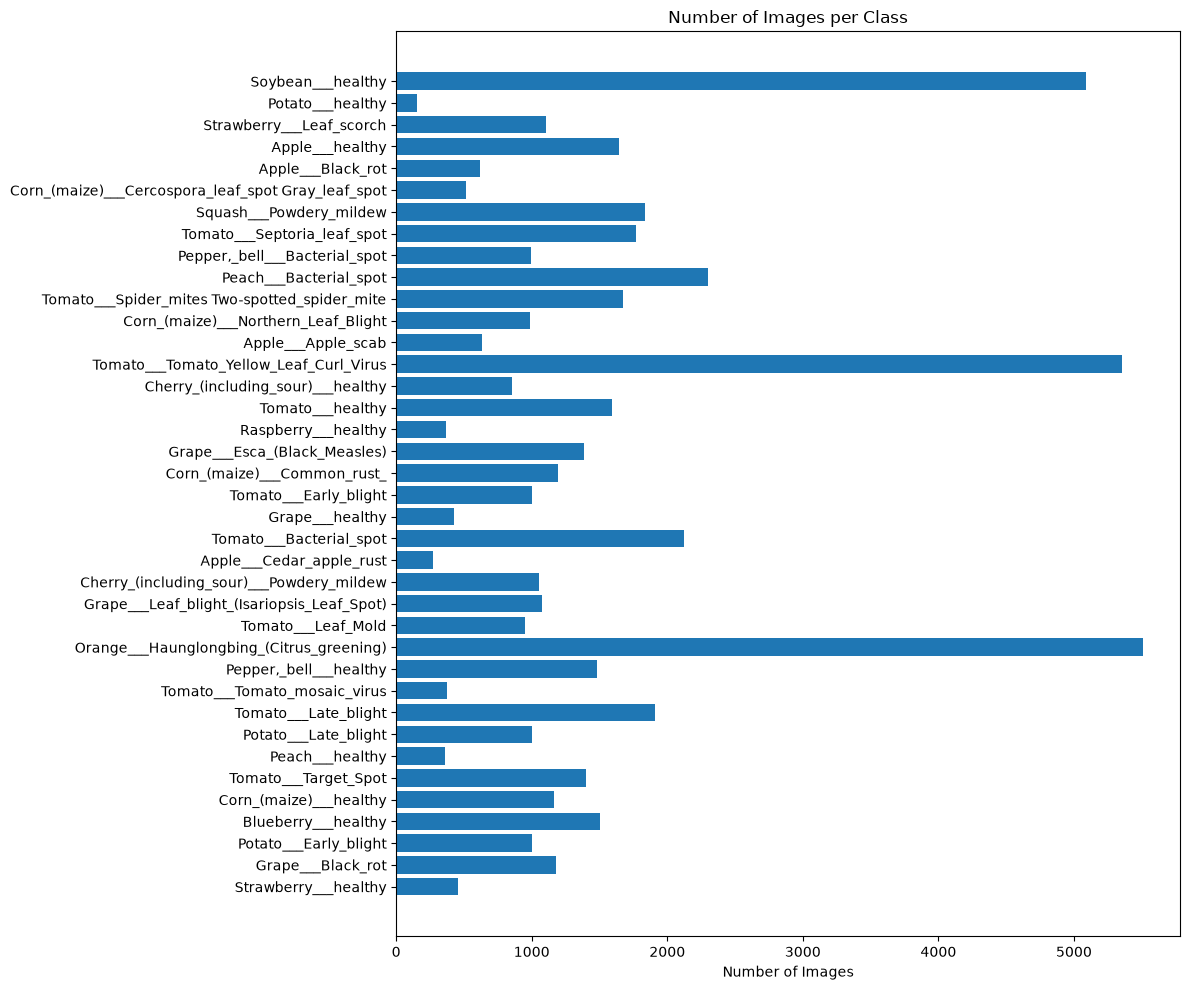

In [4]:
import matplotlib.pyplot as plt

class_counts = {}
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(12, 10))
plt.barh(list(class_counts.keys()), list(class_counts.values()))
plt.xlabel("Number of Images")
plt.title("Number of Images per Class")
plt.tight_layout()
plt.show()

In [5]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [6]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [7]:
class_names = sorted(os.listdir(data_dir))
print(class_names)
print(len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
])

In [10]:
num_classes = 38

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

/Users/mazenhany/Desktop/ssnak/.venv312/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10


/Users/mazenhany/Desktop/ssnak/.venv312/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 255s 187ms/step - accuracy: 0.7950 - loss: 0.6964 - val_accuracy: 0.9010 - val_loss: 0.3087
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 316s 233ms/step - accuracy: 0.8824 - loss: 0.3583 - val_accuracy: 0.9152 - val_loss: 0.2567
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 309s 227ms/step - accuracy: 0.8996 - loss: 0.3064 - val_accuracy: 0.9237 - val_loss: 0.2209
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 307s 226ms/step - accuracy: 0.9063 - loss: 0.2819 - val_accuracy: 0.9257 - val_loss: 0.2203
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 316s 233ms/step - accuracy: 0.9102 - loss: 0.2699 - val_accuracy: 0.9265 - val_loss: 0.2192
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 326s 240ms/step - accuracy: 0.9171 - loss: 0.2510 - val_accuracy: 0.9346 - val_loss: 0.1934
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 333s 246ms/step - accuracy: 0.9183 - loss: 0.2411 - val_accuracy: 0.9297 - val_loss: 0.2139
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 326s 240ms/step - accuracy: 0.9

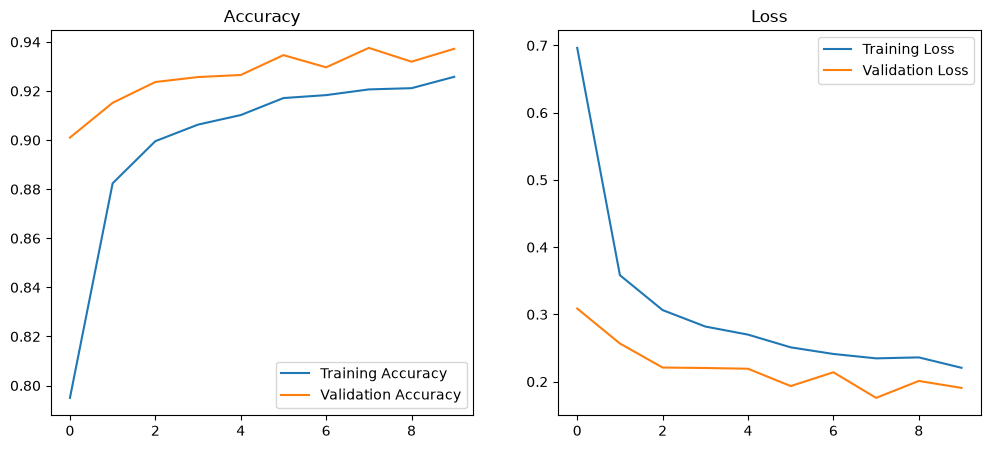

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
!pip install seaborn

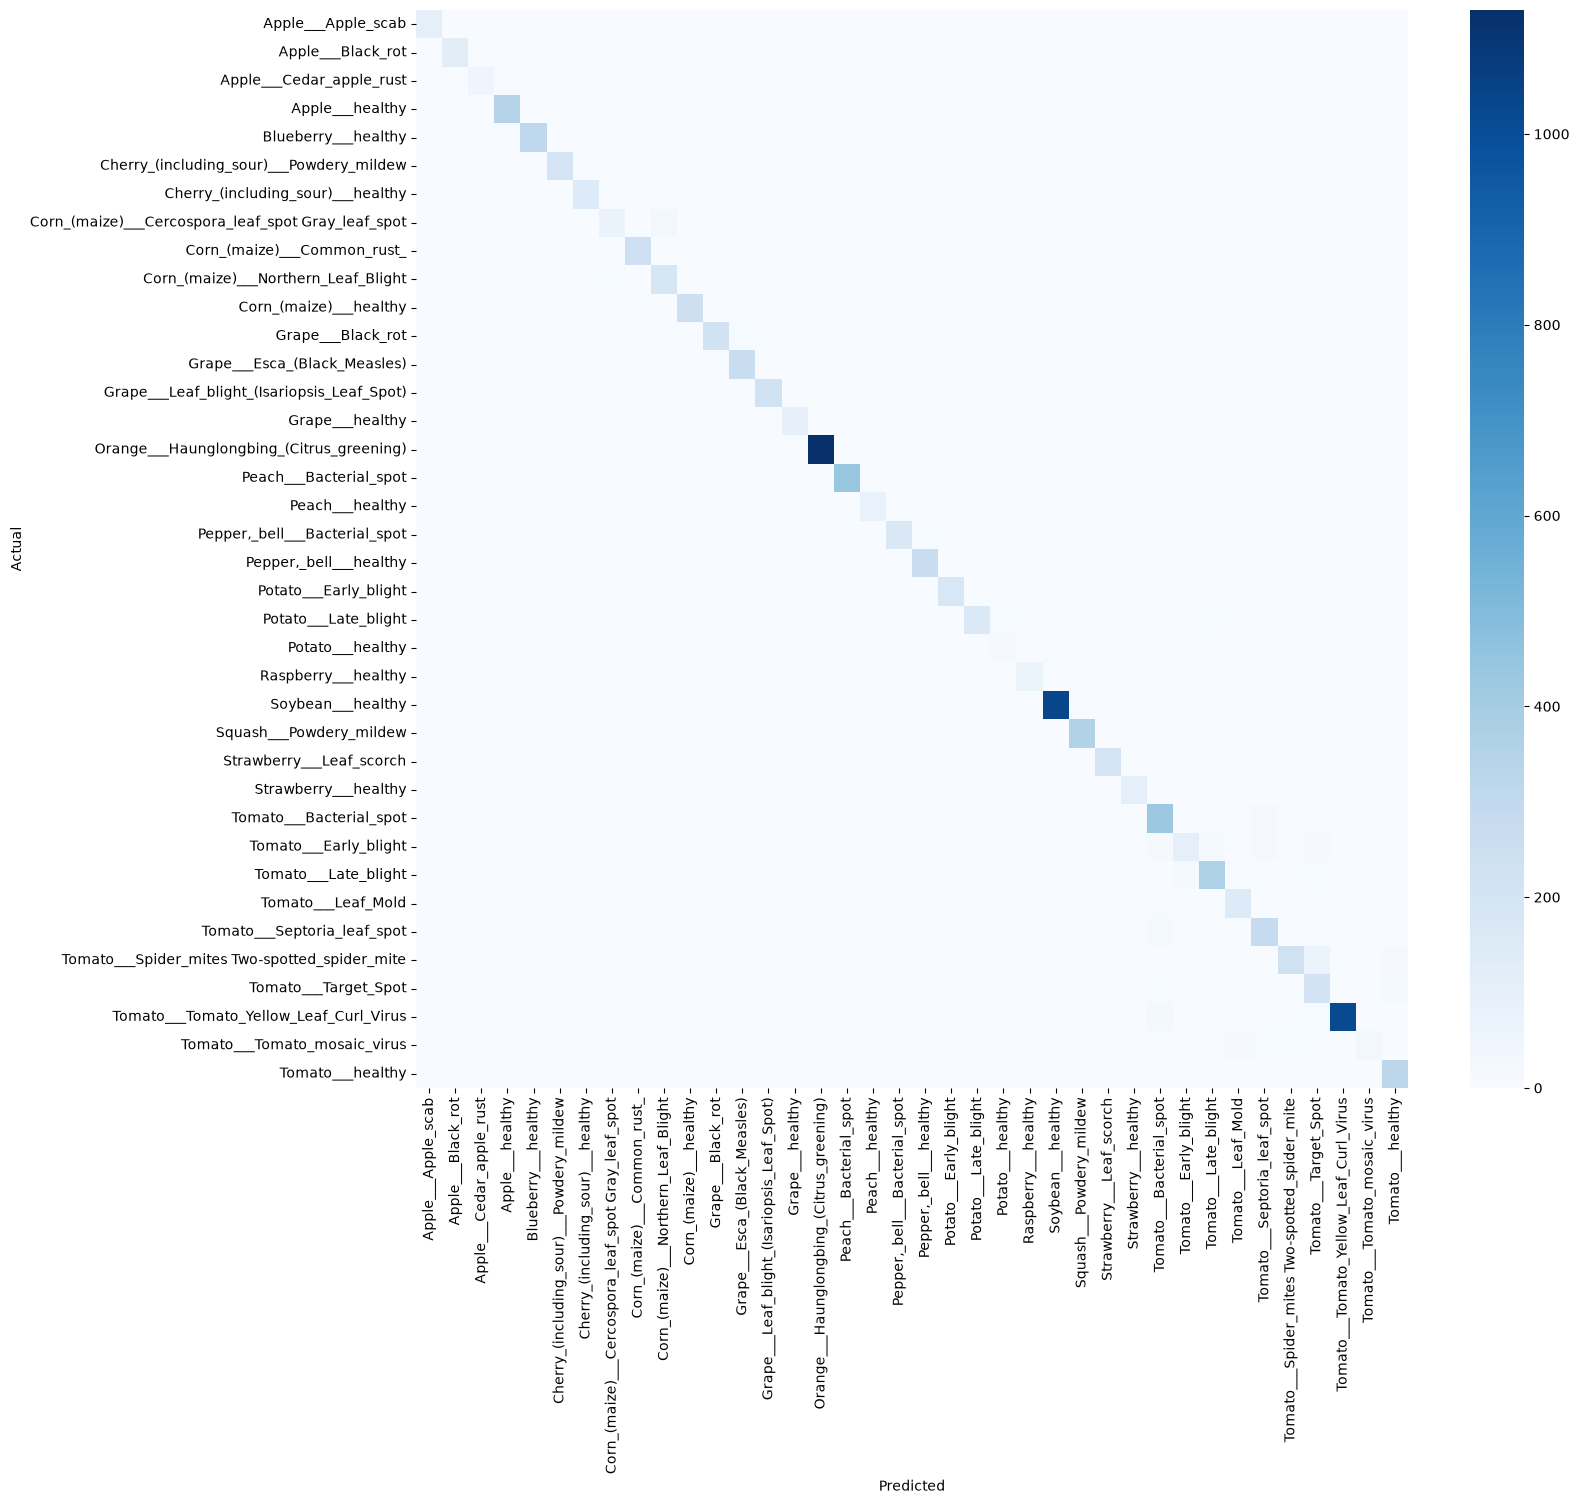

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.92      0.95       120
                                 Apple___Black_rot       0.95      0.98      0.96       124
                          Apple___Cedar_apple_rust       0.96      0.96      0.96        56
                                   Apple___healthy       0.96      0.99      0.98       348
                               Blueberry___healthy       1.00      0.97      0.98       318
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       208
                 Cherry_(including_sour)___healthy       0.95      1.00      0.97       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.86      0.72      0.78       109
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       238
               Corn_(maize)___Northern_Leaf_Blight       0.84      0.93      0.

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [16]:
model.save("plant_disease_model.keras")

with open("class_names.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")